# Exercise 4


In [2]:
import locale

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    locale.setlocale(locale.LC_ALL, 'fr_FR.utf8')
except locale.Error:
    pass

production_data_path = 'edunao-files/Donnees_France_2024_fr_cet.csv'
capacity_data_path = 'edunao-files/Capacites_France_2024.csv'

france_2024_data = pd.read_csv(production_data_path, sep=';', decimal=',', index_col=0)
france_2024_data.index = pd.to_datetime(france_2024_data.index, utc=True).tz_convert('Europe/Paris')
france_2024_data = france_2024_data.apply(pd.to_numeric, errors='coerce')

installed_capacity_data = pd.read_csv(capacity_data_path, sep=';', decimal=',', index_col=0)
installed_capacity_data.index = pd.to_datetime(installed_capacity_data.index, utc=True).tz_convert('Europe/Paris')
installed_capacity_data = installed_capacity_data.apply(pd.to_numeric, errors='coerce')

must_run_columns = ['Wind Onshore', 'Solar', 'Hydro Run-of-river and poundage']
gross_consumption_mw = france_2024_data['Load']
must_run_production_mw = france_2024_data[must_run_columns].fillna(0).sum(axis=1)
net_consumption_mw = gross_consumption_mw - must_run_production_mw
net_load_duration_mw = net_consumption_mw.sort_values(ascending=False).reset_index(drop=True)

plant_data = pd.DataFrame(
    {
        'Efficiency': [0.35, 0.40, 0.60, 0.35],
        'CO2 intensity (t/MWh_e)': [0.0, 1.0, 0.4, 0.6],
        'Capex (MEUR/MW_e)': [6.0, 1.5, 1.0, 0.7],
        'Fuel cost (EUR/MWh_th)': [5.0, 10.0, 30.0, 50.0],
    },
    index=['Nuclear', 'Coal', 'Gas CCGT', 'Oil OCGT'],
)

annuity_rate = 0.08
co2_price_eur_per_t = 80
hours_per_year = len(net_consumption_mw)

plant_data['Annual investment cost (EUR/MW/year)'] = (
    plant_data['Capex (MEUR/MW_e)'] * 1_000_000 * annuity_rate
)
plant_data['Fuel cost (EUR/MWh_e)'] = plant_data['Fuel cost (EUR/MWh_th)'] / plant_data['Efficiency']
plant_data['CO2 cost (EUR/MWh_e)'] = plant_data['CO2 intensity (t/MWh_e)'] * co2_price_eur_per_t
plant_data['Variable cost (EUR/MWh_e)'] = plant_data['Fuel cost (EUR/MWh_e)'] + plant_data['CO2 cost (EUR/MWh_e)']

operating_hours = np.arange(0, hours_per_year + 1)
screening_costs = pd.DataFrame(index=operating_hours)
for plant in plant_data.index:
    screening_costs[plant] = (
        plant_data.loc[plant, 'Annual investment cost (EUR/MW/year)']
        + plant_data.loc[plant, 'Variable cost (EUR/MWh_e)'] * operating_hours
    )

cheapest_plant = screening_costs.idxmin(axis=1)
competitive_segments = []
segment_start = 0
current_plant = cheapest_plant.iloc[0]
for hour, plant in cheapest_plant.iloc[1:].items():
    if plant != current_plant:
        competitive_segments.append((segment_start, hour - 1, current_plant))
        segment_start = hour
        current_plant = plant
competitive_segments.append((segment_start, hours_per_year, current_plant))


def load_at_duration(hours):
    if hours <= 0:
        return float(net_load_duration_mw.iloc[0])
    if hours >= len(net_load_duration_mw):
        return 0.0
    return float(net_load_duration_mw.iloc[int(np.ceil(hours))])


optimal_capacities_mw = pd.Series(0.0, index=plant_data.index)
for start_hour, end_hour, plant in competitive_segments:
    upper_load = load_at_duration(start_hour)
    lower_load = load_at_duration(end_hour + 1)
    optimal_capacities_mw.loc[plant] += max(upper_load - lower_load, 0.0)

stack_order = ['Nuclear', 'Gas CCGT', 'Oil OCGT']
stack_capacities_mw = optimal_capacities_mw[stack_order]

Month = mdates.MonthLocator(bymonthday=1)
MonthFmt = mdates.DateFormatter('%b')


## 4.1 Question

Represent the statistical distribution of daily net demand values for each hour of the day.


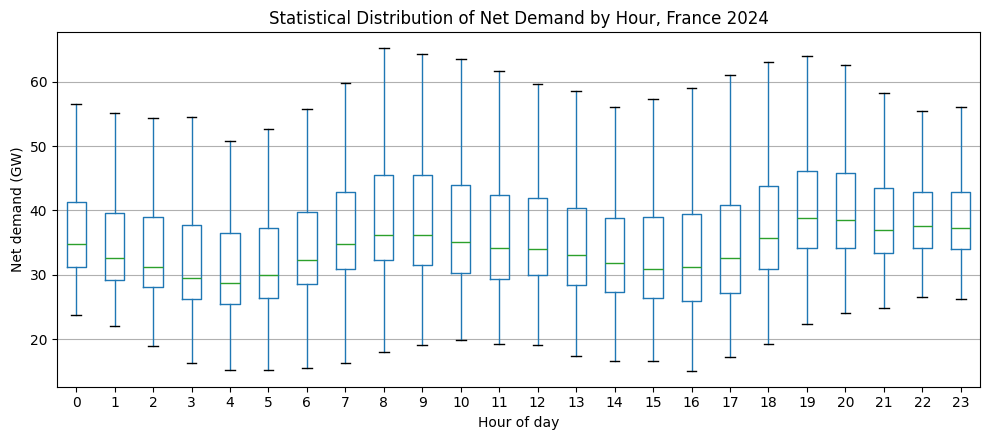

,Mean net demand (GW),Median net demand (GW),P10 (GW),P90 (GW)
Hour,,,,
0,36.99,34.85,28.81,47.88
1,35.01,32.67,26.66,46.14
2,33.83,31.24,25.54,45.21
3,32.24,29.58,23.86,43.86
4,31.34,28.71,23.12,42.56
5,32.27,29.90,23.91,43.53
6,34.76,32.38,25.26,47.32
7,37.42,34.83,25.80,51.74
8,38.85,36.18,26.34,54.12


Comment:
- The data set contains 366 local dates because 2024 is a leap year; the method is the same as for 365 daily values.
- Net demand is generally lowest during the night and early afternoon, when activity is lower or solar production contributes.
- The spread is larger during daytime and evening hours because wind, solar, weather, and weekday/weekend effects combine.


In [3]:
net_by_hour = pd.DataFrame(
    {
        'Net demand (GW)': net_consumption_mw / 1000,
        'Hour': net_consumption_mw.index.hour,
        'Date': net_consumption_mw.index.date,
    }
)

hourly_distribution = net_by_hour.pivot_table(
    index='Date',
    columns='Hour',
    values='Net demand (GW)',
    aggfunc='mean',
)

fig, ax = plt.subplots(figsize=(10, 4.5))
hourly_distribution.boxplot(ax=ax, grid=False, showfliers=False)
plt.title('Statistical Distribution of Net Demand by Hour, France 2024')
plt.xlabel('Hour of day')
plt.ylabel('Net demand (GW)')
plt.grid(True, axis='y')
fig.tight_layout()
fig.savefig('figures/exercise_4-1.pdf')
plt.show()

hourly_summary = pd.DataFrame(
    {
        'Mean net demand (GW)': hourly_distribution.mean(),
        'Median net demand (GW)': hourly_distribution.median(),
        'P10 (GW)': hourly_distribution.quantile(0.10),
        'P90 (GW)': hourly_distribution.quantile(0.90),
    }
).round(2)

display(hourly_summary)

print('Comment:')
print(f'- The data set contains {hourly_distribution.shape[0]} local dates because 2024 is a leap year; the method is the same as for 365 daily values.')
print('- Net demand is generally lowest during the night and early afternoon, when activity is lower or solar production contributes.')
print('- The spread is larger during daytime and evening hours because wind, solar, weather, and weekday/weekend effects combine.')


## 4.2 Question

Consider a storage unit with maximum power 1 MW and energy capacity 2 MWh. By charging daily during low net-demand periods and discharging during high net-demand periods, determine the annual avoided fuel cost, avoided production investment cost, and avoided CO2 emissions.


,Value,Unit
Avoided fuel cost,19428.57,EUR/year
Avoided production investment cost,56000.00,EUR/year
Avoided CO2 emissions,184.00,tCO2/year
Avoided CO2 cost equivalent,14720.00,EUR/year


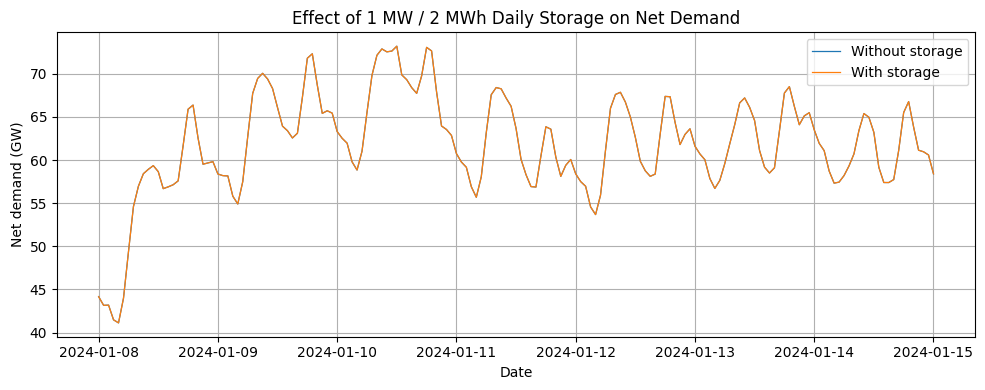

Comment:
- The storage unit shifts 2 MWh each local day from the two lowest net-demand hours to the two highest net-demand hours.
- The avoided investment is valued as 1 MW of avoided peak Oil OCGT capacity in the simplified optimal fleet.
- Annual fuel savings are 19,429 EUR/year and avoided emissions are 184.0 tCO2/year.


In [4]:
def dispatch_by_plant(load_mw):
    load_array = np.asarray(load_mw, dtype=float)
    dispatch = pd.DataFrame(0.0, index=getattr(load_mw, 'index', None), columns=plant_data.index)
    remaining = np.maximum(load_array, 0.0)

    nuclear = np.minimum(remaining, optimal_capacities_mw.loc['Nuclear'])
    dispatch['Nuclear'] = nuclear
    remaining -= nuclear

    gas = np.minimum(remaining, optimal_capacities_mw.loc['Gas CCGT'])
    dispatch['Gas CCGT'] = gas
    remaining -= gas

    oil = np.minimum(remaining, optimal_capacities_mw.loc['Oil OCGT'])
    dispatch['Oil OCGT'] = oil
    remaining -= oil

    if np.nanmax(remaining) > 1e-6:
        raise ValueError('The simplified dispatchable fleet is too small for this demand profile.')

    return dispatch


storage_adjustment_mw = pd.Series(0.0, index=net_consumption_mw.index)

for _, daily_net in net_consumption_mw.groupby(net_consumption_mw.index.date):
    charge_hours = daily_net.nsmallest(2).index
    discharge_hours = daily_net.nlargest(2).index
    storage_adjustment_mw.loc[charge_hours] += 1.0
    storage_adjustment_mw.loc[discharge_hours] -= 1.0

net_with_storage_mw = net_consumption_mw + storage_adjustment_mw

dispatch_without_storage_mw = dispatch_by_plant(net_consumption_mw)
dispatch_with_storage_mw = dispatch_by_plant(net_with_storage_mw)

fuel_cost_without_storage = (dispatch_without_storage_mw.sum() * plant_data['Fuel cost (EUR/MWh_e)']).sum()
fuel_cost_with_storage = (dispatch_with_storage_mw.sum() * plant_data['Fuel cost (EUR/MWh_e)']).sum()
co2_without_storage_t = (dispatch_without_storage_mw.sum() * plant_data['CO2 intensity (t/MWh_e)']).sum()
co2_with_storage_t = (dispatch_with_storage_mw.sum() * plant_data['CO2 intensity (t/MWh_e)']).sum()

avoided_fuel_cost_eur = fuel_cost_without_storage - fuel_cost_with_storage
avoided_co2_t = co2_without_storage_t - co2_with_storage_t
avoided_co2_cost_eur = avoided_co2_t * co2_price_eur_per_t
avoided_investment_cost_eur = plant_data.loc['Oil OCGT', 'Annual investment cost (EUR/MW/year)'] * 1.0

storage_results = pd.DataFrame(
    {
        'Value': [
            avoided_fuel_cost_eur,
            avoided_investment_cost_eur,
            avoided_co2_t,
            avoided_co2_cost_eur,
        ],
        'Unit': ['EUR/year', 'EUR/year', 'tCO2/year', 'EUR/year'],
    },
    index=[
        'Avoided fuel cost',
        'Avoided production investment cost',
        'Avoided CO2 emissions',
        'Avoided CO2 cost equivalent',
    ],
)

display(storage_results.round(2))

week_start = pd.Timestamp('2024-01-08', tz='Europe/Paris')
week_end = pd.Timestamp('2024-01-15', tz='Europe/Paris')
week_slice = slice(week_start, week_end)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(net_consumption_mw.loc[week_slice].index, net_consumption_mw.loc[week_slice] / 1000, linewidth=.9, label='Without storage')
ax.plot(net_with_storage_mw.loc[week_slice].index, net_with_storage_mw.loc[week_slice] / 1000, linewidth=.9, label='With storage')
plt.title('Effect of 1 MW / 2 MWh Daily Storage on Net Demand')
plt.xlabel('Date')
plt.ylabel('Net demand (GW)')
plt.grid(True)
plt.legend()
fig.tight_layout()
fig.savefig('figures/exercise_4-2.pdf')
plt.show()

print('Comment:')
print('- The storage unit shifts 2 MWh each local day from the two lowest net-demand hours to the two highest net-demand hours.')
print('- The avoided investment is valued as 1 MW of avoided peak Oil OCGT capacity in the simplified optimal fleet.')
print(f'- Annual fuel savings are {avoided_fuel_cost_eur:,.0f} EUR/year and avoided emissions are {avoided_co2_t:.1f} tCO2/year.')


## 4.3 Question

Consider the charging of 1000 electric vehicles, each with maximum charging power of 7 kW. Charging happens once per weekend and once midweek, on Wednesday or Thursday. Determine the wind and PV capacities to install to satisfy as much of this specific demand as possible without curtailment, the annual fuel quantities and costs needed for the remaining recharge demand, the investment cost of the required dispatchable production capacity, and the CO2 emissions generated.


Total EV charging energy scheduled: 2106.0 MWh/year
Renewable energy supplied without curtailment: 817.9 MWh/year (38.8%)
Dispatchable backup energy required: 1288.1 MWh/year
Number of charging sessions placed: 104


,Energy served by 1 MW (MWh/year),Installed capacity without curtailment (MW),Annual energy supplied (MWh/year)
Wind Onshore,87.74,7.88,691.21
Solar PV,66.99,1.90,126.65


,Backup capacity (MW),Backup energy (MWh/year),Fuel quantity (MWh_th/year),Fuel cost (EUR/year),Investment cost (EUR/year),CO2 emissions (tCO2/year)
Nuclear,6.56,879.01,2511.44,12557.22,3148315.46,0.00
Coal,0.00,0.00,0.00,0.00,0.00,0.00
Gas CCGT,6.62,409.13,681.89,20456.67,529392.40,163.65
Oil OCGT,0.00,0.00,0.00,0.00,0.00,0.00


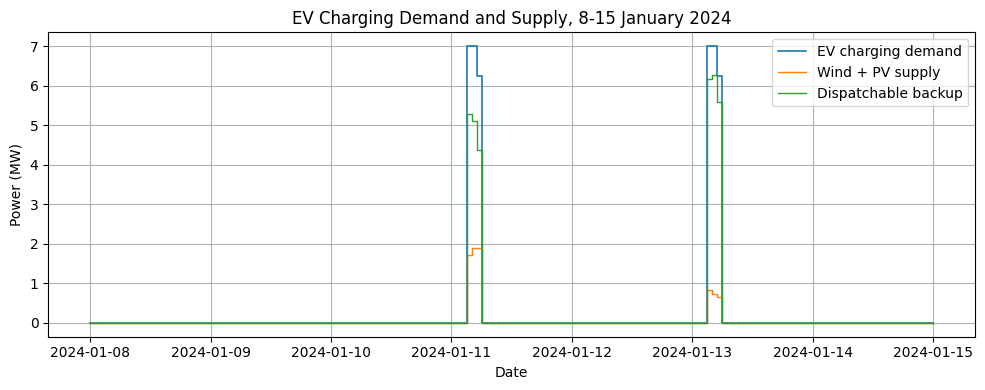

Comment:
- Charging sessions are placed in the lowest net-demand consecutive hours inside each Wednesday/Thursday and weekend window.
- The renewable build is selected greedily by annual charging energy supplied per MW, then capped so wind plus PV never exceeds the charging demand.
- Renewable capex is not provided in the assignment data, so the investment table reports the dispatchable backup investment using the Exercise 3 plant costs.


In [5]:
vehicle_count = 1000
vehicle_max_charging_power_kw = 7
fleet_max_charging_power_mw = vehicle_count * vehicle_max_charging_power_kw / 1000
annual_distance_km_per_vehicle = 11_700
vehicle_consumption_kwh_per_100km = 18
charges_per_year = 52 * 2

annual_energy_per_vehicle_kwh = annual_distance_km_per_vehicle * vehicle_consumption_kwh_per_100km / 100
energy_per_charge_mwh = vehicle_count * annual_energy_per_vehicle_kwh / charges_per_year / 1000
full_power_hours = int(energy_per_charge_mwh // fleet_max_charging_power_mw)
last_hour_power_mw = energy_per_charge_mwh - full_power_hours * fleet_max_charging_power_mw
charge_shape_mw = [fleet_max_charging_power_mw] * full_power_hours
if last_hour_power_mw > 1e-9:
    charge_shape_mw.append(last_hour_power_mw)
charge_duration_hours = len(charge_shape_mw)

ev_charging_mw = pd.Series(0.0, index=net_consumption_mw.index)

def place_charge_in_window(window_index):
    if len(window_index) < charge_duration_hours:
        return
    window_net = net_consumption_mw.loc[window_index]
    rolling_net = window_net.rolling(charge_duration_hours).sum()
    end_time = rolling_net.idxmin()
    if pd.isna(end_time):
        return
    end_position = window_net.index.get_loc(end_time)
    selected_index = window_net.index[end_position - charge_duration_hours + 1:end_position + 1]
    ev_charging_mw.loc[selected_index] += charge_shape_mw

for week_start in pd.date_range(
    net_consumption_mw.index[0].normalize(),
    net_consumption_mw.index[-1].normalize(),
    freq='W-MON',
    tz='Europe/Paris',
):
    midweek_start = week_start + pd.Timedelta(days=2)
    midweek_end = week_start + pd.Timedelta(days=4)
    weekend_start = week_start + pd.Timedelta(days=5)
    weekend_end = week_start + pd.Timedelta(days=7)

    midweek_index = net_consumption_mw.loc[(net_consumption_mw.index >= midweek_start) & (net_consumption_mw.index < midweek_end)].index
    weekend_index = net_consumption_mw.loc[(net_consumption_mw.index >= weekend_start) & (net_consumption_mw.index < weekend_end)].index

    place_charge_in_window(midweek_index)
    place_charge_in_window(weekend_index)

renewable_profiles_per_mw = pd.DataFrame(
    {
        'Wind Onshore': france_2024_data['Wind Onshore'] / installed_capacity_data.iloc[0]['Wind Onshore'],
        'Solar PV': france_2024_data['Solar'] / installed_capacity_data.iloc[0]['Solar'],
    },
    index=france_2024_data.index,
).fillna(0)

renewable_energy_per_mw_mwh = pd.Series(
    {
        source: np.minimum(renewable_profiles_per_mw[source], ev_charging_mw).sum()
        for source in renewable_profiles_per_mw.columns
    }
)
renewable_order = renewable_energy_per_mw_mwh.sort_values(ascending=False).index

remaining_ev_demand_mw = ev_charging_mw.copy()
renewable_supply_mw = pd.DataFrame(0.0, index=ev_charging_mw.index, columns=renewable_profiles_per_mw.columns)
renewable_capacities_mw = pd.Series(0.0, index=renewable_profiles_per_mw.columns)

for source in renewable_order:
    profile = renewable_profiles_per_mw[source]
    feasible = (profile > 1e-9) & (remaining_ev_demand_mw > 1e-9)
    if not feasible.any():
        continue
    capacity_limit_mw = (remaining_ev_demand_mw.loc[feasible] / profile.loc[feasible]).min()
    renewable_capacities_mw.loc[source] = capacity_limit_mw
    renewable_supply_mw[source] = np.minimum(profile * capacity_limit_mw, remaining_ev_demand_mw)
    remaining_ev_demand_mw = remaining_ev_demand_mw - renewable_supply_mw[source]

backup_dispatch_increment_mw = (
    dispatch_by_plant(net_consumption_mw + remaining_ev_demand_mw)
    - dispatch_by_plant(net_consumption_mw)
)
backup_energy_mwh = backup_dispatch_increment_mw.sum().clip(lower=0)
backup_capacity_mw = backup_dispatch_increment_mw.max().clip(lower=0)
backup_fuel_mwh_th = backup_energy_mwh / plant_data['Efficiency']
backup_fuel_cost_eur = backup_energy_mwh * plant_data['Fuel cost (EUR/MWh_e)']
backup_co2_t = backup_energy_mwh * plant_data['CO2 intensity (t/MWh_e)']
backup_investment_cost_eur = backup_capacity_mw * plant_data['Annual investment cost (EUR/MW/year)']

renewable_summary = pd.DataFrame(
    {
        'Energy served by 1 MW (MWh/year)': renewable_energy_per_mw_mwh,
        'Installed capacity without curtailment (MW)': renewable_capacities_mw,
        'Annual energy supplied (MWh/year)': renewable_supply_mw.sum(),
    }
).round(2)

dispatchable_summary = pd.DataFrame(
    {
        'Backup capacity (MW)': backup_capacity_mw,
        'Backup energy (MWh/year)': backup_energy_mwh,
        'Fuel quantity (MWh_th/year)': backup_fuel_mwh_th,
        'Fuel cost (EUR/year)': backup_fuel_cost_eur,
        'Investment cost (EUR/year)': backup_investment_cost_eur,
        'CO2 emissions (tCO2/year)': backup_co2_t,
    }
).fillna(0).round(2)

charging_energy_mwh = ev_charging_mw.sum()
renewable_energy_mwh = renewable_supply_mw.sum().sum()
backup_energy_total_mwh = remaining_ev_demand_mw.sum()

print(f'Total EV charging energy scheduled: {charging_energy_mwh:.1f} MWh/year')
print(f'Renewable energy supplied without curtailment: {renewable_energy_mwh:.1f} MWh/year ({renewable_energy_mwh / charging_energy_mwh:.1%})')
print(f'Dispatchable backup energy required: {backup_energy_total_mwh:.1f} MWh/year')
print(f'Number of charging sessions placed: {int((ev_charging_mw > 0).sum() / charge_duration_hours)}')

display(renewable_summary)
display(dispatchable_summary)

week_start = pd.Timestamp('2024-01-08', tz='Europe/Paris')
week_end = pd.Timestamp('2024-01-15', tz='Europe/Paris')
week_slice = slice(week_start, week_end)

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(ev_charging_mw.loc[week_slice].index, ev_charging_mw.loc[week_slice], where='post', linewidth=1.2, label='EV charging demand')
ax.step(renewable_supply_mw.loc[week_slice].index, renewable_supply_mw.loc[week_slice].sum(axis=1), where='post', linewidth=1.0, label='Wind + PV supply')
ax.step(remaining_ev_demand_mw.loc[week_slice].index, remaining_ev_demand_mw.loc[week_slice], where='post', linewidth=1.0, label='Dispatchable backup')
plt.title('EV Charging Demand and Supply, 8-15 January 2024')
plt.xlabel('Date')
plt.ylabel('Power (MW)')
plt.grid(True)
plt.legend()
fig.tight_layout()
fig.savefig('figures/exercise_4-3.pdf')
plt.show()

print('Comment:')
print('- Charging sessions are placed in the lowest net-demand consecutive hours inside each Wednesday/Thursday and weekend window.')
print('- The renewable build is selected greedily by annual charging energy supplied per MW, then capped so wind plus PV never exceeds the charging demand.')
print('- Renewable capex is not provided in the assignment data, so the investment table reports the dispatchable backup investment using the Exercise 3 plant costs.')
